## TODO
- [x] Adicionar dados de VRA da ANAC
    - [x] Merge dos dados para cada ano
    - [x] Importar apenas as colunas de interesse para o dataframe
- [x] Completar as analise sobre o crescimento do movimento areo
- [ ] agregar ocorrencias por aeroporto
    [ ] agregar ocorrencias por cidade
    [ ] agregar ocorrencias por fase de voo - source aeronaves
    [ ] mapear fase de voo para o possivel aeroporto de ocorrencia
- [x] agregar movimentos de saida VRA
- [x] agregar movimentos de chegada VRA
- [ ] media dos numeros de assentos das aeronaves - estimar transporte diario de passageiros?
- [ ] onde encontrar dados sobre movimentacao de passageiros?? 


In [48]:
# load data into dataframes
import sys
from pathlib import Path

import pandas as pd
import plotly.express as ptex
import matplotlib.pyplot as plt
from os import path
from glob import glob

# allow `from utils ...` whether cwd is `source/` or project root
for _p in (Path.cwd(), Path.cwd() / "source"):
    if (_p / "utils" / "dataframe_operations.py").is_file():
        if str(_p) not in sys.path:
            sys.path.insert(0, str(_p))
        break

from utils.dataframe_operations import DataFrameOperations, load_datasource_urls

datasources = load_datasource_urls()
loader = DataFrameOperations()

df_aeronave = loader.load_dataframe(datasources["aeronave"])
# df_fator_contribuicao = loader.load_dataframe(datasources["fator_contribuicao"])
# df_tipo_de_ocorrencia = loader.load_dataframe(datasources["tipo_de_ocorrencia"])
df_ocorrencia = loader.load_dataframe(datasources["ocorrencia"])
# df_recomendacao_cenipa = loader.load_dataframe(datasources["recomendacao_cenipa"])

df_ocorrencia.head()

,codigo_ocorrencia,codigo_ocorrencia1,codigo_ocorrencia2,codigo_ocorrencia3,codigo_ocorrencia4,ocorrencia_classificacao,ocorrencia_latitude,ocorrencia_longitude,ocorrencia_cidade,ocorrencia_uf,...,ocorrencia_dia,ocorrencia_hora,investigacao_aeronave_liberada,investigacao_status,divulgacao_relatorio_numero,divulgacao_relatorio_publicado,divulgacao_dia_publicacao,total_recomendacoes,total_aeronaves_envolvidas,ocorrencia_saida_pista
0,87125,87125,87125,87125,87125,INCIDENTE,-7.219166666666,-39.26944444444,JUAZEIRO DO NORTE,CE,...,11/05/2025,04:20:00,SIM,FINALIZADA,***,NÃO,NaN,0,1,NÃO
1,87124,87124,87124,87124,87124,INCIDENTE,-18.88361111111,-48.22527777777,UBERLÂNDIA,MG,...,08/05/2025,14:00:00,SIM,FINALIZADA,***,NÃO,NaN,0,1,NÃO
2,87123,87123,87123,87123,87123,INCIDENTE,-23.43555555555,-46.47305555555,GUARULHOS,SP,...,09/05/2025,18:45:00,SIM,FINALIZADA,***,NÃO,NaN,0,1,NÃO
3,87122,87122,87122,87122,87122,INCIDENTE,-29.71083333333,-53.69222222222,SANTA MARIA,RS,...,04/05/2025,14:45:00,SIM,FINALIZADA,***,NÃO,NaN,0,1,NÃO
4,87121,87121,87121,87121,87121,INCIDENTE,-20.81722222222,-49.40694444444,SÃO JOSÉ DO RIO PRETO,SP,...,10/05/2025,10:00:00,SIM,FINALIZADA,***,NÃO,NaN,0,1,NÃO


### Analise do conjunto de dados de "Ocorrencias".
Na aviação, as ocorrências operacionais ou de segurança são classificadas em acidentes, incidentes graves e apenas incidentes. Os incidentes são aqueles em que a ocorrência afeta o funcionamente e compromete a segurança operacional, porém sem danos e sem feridos. Os incidentes graves envolvem uma falha séria de segurança, mas ainda sem a ocorrência de feridos. Os acidentes são ocorrências em que ocorre dano grave à aeronave e ou/feridos.
Vamos observar como estes dados estao dispostos por meio de algumas ferramentas de visualizalção.
Portanto vamos observar primeiramente a diferença da taxa de acidentes e incidentes registrados no dataset ocorrencias

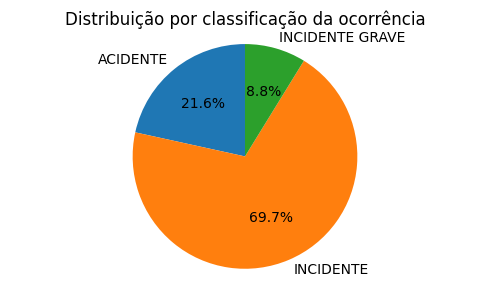

In [14]:
# Pie chart: distribuição por classificação (ACIDENTE, INCIDENTE, INCIDENTE GRAVE)
contagem = df_ocorrencia['ocorrencia_classificacao'].value_counts()
categorias = ['ACIDENTE', 'INCIDENTE', 'INCIDENTE GRAVE']
contagem_filtrada = contagem.reindex(categorias).fillna(0).astype(int)

plt.figure(figsize=(5, 3))
plt.pie(contagem_filtrada, labels=contagem_filtrada.index, autopct='%1.1f%%', startangle=90)
plt.title('Distribuição por classificação da ocorrência')
plt.axis('equal')
plt.tight_layout()
plt.show()

Observando o gráfico, nota-se que a maioria das ocorrências encontra-se na categoria "Incidentes". No entanto, os registros na base de dados começam por 2007 e é sabido que desde então o perfil da aviação no Brasil passou por inúmeras mudanças. Para trazer um pouco mais de clareza para essa distribuição, vamos primeiro olhar para a evolução dos números de ocorrências registradas ano a ano, e então, para cada ano, focar na proporção acidentes e incidentes

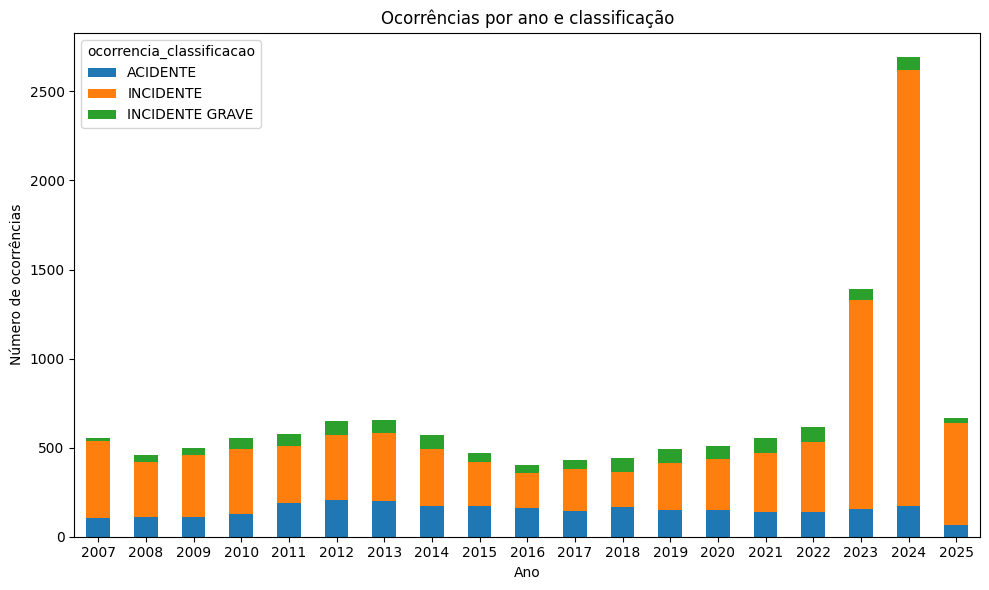

In [15]:
#TRATAMENTO DOS DADOS: Originalmente essa coluna era do tipo string, no entanto para melhor analisar e manipular os dados
# o tipo de dados da coluna foi alterado para datetime usando recursos da biblioteca pandas
from narwhals._compliant import group_by


df_ocorrencia['ocorrencia_dia'] = pd.to_datetime(
    df_ocorrencia['ocorrencia_dia'],
    format='%d/%m/%Y',
    dayfirst=True,
    errors='coerce'
)

#evolução dos regitros das ocorrências por ano
years = df_ocorrencia['ocorrencia_dia'].dt.year
count_ocorr_ano = years.value_counts().sort_index()

ocorrencias_por_ano = ptex.bar(count_ocorr_ano)
ocorrencias_por_ano.show()

#Distribuição por ano de quantas ocorrencias foram acidentes e quantas ocorrências foram incidentes
df_valid = df_ocorrencia[df_ocorrencia['ocorrencia_dia'].notna()].copy()
df_valid['ano'] = df_valid['ocorrencia_dia'].dt.year

grouped_counts = (
    df_valid
    .groupby(['ano', 'ocorrencia_classificacao'])
    .size()
)

tabela = grouped_counts.unstack(fill_value=0).sort_index()

ax = tabela.plot(
    kind='bar',
    stacked=True,
    figsize=(10, 6)
)
ax.set_xlabel('Ano')
ax.set_ylabel('Número de ocorrências')
ax.set_title('Ocorrências por ano e classificação')
plt.xticks(rotation=0)  # years horizontal (optional)
plt.tight_layout()
plt.show()



In [ ]:
import math
from utils.dataframe_operations import filter_by_year

df_ocorrencia_brasil = df_ocorrencia[
    df_ocorrencia['ocorrencia_pais'].str.upper() == 'BRASIL'
]

df_ocorrencia_brasil = filter_by_year(df_ocorrencia_brasil, 'ocorrencia_dia', [2023, 2024])

lat_col = pd.to_numeric(df_ocorrencia_brasil["ocorrencia_latitude"], errors="coerce").dropna()
lon_col = pd.to_numeric(df_ocorrencia_brasil["ocorrencia_longitude"], errors="coerce").dropna()

lat_min, lat_max = lat_col.min(), lat_col.max()
lon_min, lon_max = lon_col.min(), lon_col.max()

center_lat = (lat_min + lat_max) / 2
center_lon = (lon_min + lon_max) / 2
zoom = math.log2(360 / max(lat_max - lat_min, lon_max - lon_min)) - 1

fig = ptex.scatter_map(
    df_ocorrencia_brasil,
    lat="ocorrencia_latitude",
    lon="ocorrencia_longitude",
    hover_name="ocorrencia_cidade",
    color="ocorrencia_classificacao",
    color_discrete_map={
        "INCIDENTE": "#459e18",
        "INCIDENTE GRAVE": "#f7a831",
        "ACIDENTE": "#EF553B",
    },
    zoom=zoom,
    center={"lat": center_lat, "lon": center_lon},
    map_style="carto-positron",
    title="Ocorrências Aéreas por Localização — Brasil"
)

fig.update_layout(
    height=700,
    width=1200,
    legend=dict(
        orientation="h",
        yanchor="bottom",
        y=1.02,
        xanchor="center",
        x=0.5,
        title_text=""
    )
)

fig.show()

In [47]:
from utils.dataframe_operations import filter_by_year

df_ocorrencia_recente = filter_by_year(df_ocorrencia, 'ocorrencia_dia', [2023, 2024])

df_acidentes_cidade = (
    df_ocorrencia_recente[df_ocorrencia_recente['ocorrencia_classificacao'] == 'ACIDENTE']
    .groupby('ocorrencia_cidade').size()
    .reset_index(name='contagem')
    .sort_values('contagem', ascending=False)
)

df_incidentes_cidade = (
    df_ocorrencia_recente[df_ocorrencia_recente['ocorrencia_classificacao'] == 'INCIDENTE']
    .groupby('ocorrencia_cidade').size()
    .reset_index(name='contagem')
    .sort_values('contagem', ascending=False)
)

df_incidentes_graves_cidade = (
    df_ocorrencia_recente[df_ocorrencia_recente['ocorrencia_classificacao'] == 'INCIDENTE GRAVE']
    .groupby('ocorrencia_cidade').size()
    .reset_index(name='contagem')
    .sort_values('contagem', ascending=False)
)

print("ACIDENTES")
display(df_acidentes_cidade.head())
print("INCIDENTES")
display(df_incidentes_cidade.head())
print("INCIDENTES GRAVES")
display(df_incidentes_graves_cidade.head())



ACIDENTES


,ocorrencia_cidade,contagem
39,BRASNORTE,5
228,TERESINA,4
71,CUIABÁ,4
36,BRAGANÇA PAULISTA,4
32,BOA VISTA,3


INCIDENTES


,ocorrencia_cidade,contagem
71,GUARULHOS,389
153,RIO DE JANEIRO,342
181,SÃO PAULO,268
33,CAMPINAS,208
28,BRASÍLIA,169


INCIDENTES GRAVES


,ocorrencia_cidade,contagem
81,RIO DE JANEIRO,5
0,ALTAMIRA,3
42,CURITIBA,3
23,CAMPO GRANDE,3
94,SÃO DESIDÉRIO,2


In [ ]:
media_acidentes = df_acidentes_cidade['contagem'].mean()
media_incidentes = df_incidentes_cidade['contagem'].mean()
media_incidentes_graves = df_incidentes_graves_cidade['contagem'].mean()

mediana_acidentes = df_acidentes_cidade['contagem'].median()
mediana_incidentes = df_incidentes_cidade['contagem'].median()
mediana_incidentes_graves = df_incidentes_graves_cidade['contagem'].median()

std_acidentes = df_acidentes_cidade['contagem'].std()
std_incidentes = df_incidentes_cidade['contagem'].std()
std_incidentes_graves = df_incidentes_graves_cidade['contagem'].std()

print(f"Média de acidentes:                 {media_acidentes:.2f}")
print(f"Mediana de acidentes:               {mediana_acidentes:.2f}")
print(f"Desvio padrão de acidentes:         {std_acidentes:.2f}")

print(f"Média de incidentes:                {media_incidentes:.2f}")
print(f"Mediana de incidentes:              {mediana_incidentes:.2f}")
print(f"Desvio padrão de incidentes:        {std_incidentes:.2f}")

print(f"Média de incidentes graves:         {media_incidentes_graves:.2f}")
print(f"Mediana de incidentes graves:       {mediana_incidentes_graves:.2f}")
print(f"Desvio padrão de incidentes graves: {std_incidentes_graves:.2f}")





Média de acidentes:                 1.3043478260869565
Mediana de acidentes:               1.0
Desvio padrão de acidentes:         0.6158141384704452
Média de incidentes:                17.75
Mediana de incidentes:              2.0
Desvio padrão de incidentes:        49.36813804659025
Média de incidentes graves:         1.209090909090909
Mediana de incidentes graves:       1.0
Desvio padrão de incidentes graves: 0.5762175708076097


Agora observando os dados seccionados, percebe-se que o número de acidentes não varia tanto quanto parecia quando se olhava apenas o número de ocorrências por ano. O que realmente houve durante os anos de 2023 e 2024 foi um grande incremento no número de incidentes, enquanto o a variação no número de acidentes é mínima. Não sabemos ainda o que pode ter ocasionado esse aumento expressivo no número de incidentes. Afinal, até aqui foram usadas ferramentas de visualização de dados declarativas, que apenas facilitam a entender a disposição dos dados disponíveis dentro dos dataframes.

Para um aprofundamento na questão da segurança, vamos integrar a essa análise um novo conjunto de dados, dessa vez da ANAC (Agencia Nacional da Aviação Civil). Pela política de dados abertos, a ANAC divulga anualmente o VRA: Registro de Voos ativos. Por meio desses dados poderemos observar como o movimento aéreo se comportou durante o período de interesse. Poderemos, por exemplo, verificar se o aumento na taxa de acidentes

In [17]:
cols=["Sigla ICAO Empresa Aérea","Empresa Aérea","Número de Assentos","Sigla ICAO Aeroporto Origem",
       "Descrição Aeroporto Origem","Sigla ICAO Aeroporto Destino","Descrição Aeroporto Destino","Situação Voo"]
df_vra_2023 = loader.load_dataframe(datasources["vra_2023_01"],
datasources["vra_2023_02"],
datasources["vra_2023_03"],
datasources["vra_2023_04"],
datasources["vra_2023_05"],
datasources["vra_2023_06"],
datasources["vra_2023_07"],
datasources["vra_2023_08"],
datasources["vra_2023_09"],
datasources["vra_2023_10"],     
datasources["vra_2023_11"],
datasources["vra_2023_12"],
usecols=cols,encoding="utf-8")

df_vra_2024 = loader.load_dataframe(datasources["vra_2024_01"],
datasources["vra_2024_02"],
datasources["vra_2024_03"],
datasources["vra_2024_04"],
datasources["vra_2024_05"],
datasources["vra_2024_06"], 
datasources["vra_2024_07"],
datasources["vra_2024_08"],
datasources["vra_2024_09"],
datasources["vra_2024_10"],
datasources["vra_2024_11"],
datasources["vra_2024_12"],
usecols=cols,encoding="utf-8")

In [18]:
from IPython.display import display

print(df_vra_2023.shape)
print(df_vra_2024.shape)

(981206, 8)
(987868, 8)


In [19]:
from collections import defaultdict
def _group_and_filter_VRA_BR(df):
    group_by_airport = defaultdict(lambda: {"pousos": 0, "decolagens": 0})
    AEROPORTO_DECOLAGEM = "Descrição Aeroporto Origem"
    AEROPORTO_POUSO = "Descrição Aeroporto Destino"
    SITUACAO_VOO = "Situação Voo"
    cols = list(df.columns)
    i_sit = cols.index(SITUACAO_VOO)
    i_orig = cols.index(AEROPORTO_DECOLAGEM)
    i_dest = cols.index(AEROPORTO_POUSO)

    for row in df.itertuples(index=False, name=None):
        if row[i_sit] != "REALIZADO":
            continue
        aeroporto_decolagem = row[i_orig]
        aeroporto_pouso = row[i_dest]

        if pd.notna(aeroporto_decolagem) and "brasil" in str(aeroporto_decolagem).lower():
            group_by_airport[aeroporto_decolagem]["decolagens"] += 1
        if pd.notna(aeroporto_pouso) and "brasil" in str(aeroporto_pouso).lower():
            group_by_airport[aeroporto_pouso]["pousos"] += 1

    out = pd.DataFrame.from_dict(group_by_airport, orient="index")
    out["movimentacao_total"] = out["pousos"] + out["decolagens"]
    return out.sort_values("movimentacao_total", ascending=False)

contagem_movimentos_br_2024 = _group_and_filter_VRA_BR(df_vra_2024)
contagem_movimentos_br_2023 = _group_and_filter_VRA_BR(df_vra_2023)


In [20]:
media2023 = contagem_movimentos_br_2023["movimentacao_total"].mean()
media2024 = contagem_movimentos_br_2024["movimentacao_total"].mean()
median2023 = contagem_movimentos_br_2023["movimentacao_total"].median()
median2024 = contagem_movimentos_br_2024["movimentacao_total"].median()
stddev2023 = contagem_movimentos_br_2023["movimentacao_total"].std()
stddev2024 = contagem_movimentos_br_2024["movimentacao_total"].std()

print(f"Média         2023: {media2023:.2f}")
print(f"Média         2024: {media2024:.2f}")
print(f"Mediana       2023: {median2023:.2f}")
print(f"Mediana       2024: {median2024:.2f}")
print(f"Desvio Padrão 2023: {stddev2023:.2f}")
print(f"Desvio Padrão 2024: {stddev2024:.2f}")



Média         2023: 9014.10
Média         2024: 9066.37
Mediana       2023: 528.00
Mediana       2024: 509.00
Desvio Padrão 2023: 29344.22
Desvio Padrão 2024: 29831.08


In [21]:
from utils.paths import PROCESSED_DIR
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
contagem_movimentos_br_2023.to_csv(PROCESSED_DIR / "contagem_movimentos_br_2023.csv", sep=";")
contagem_movimentos_br_2024.to_csv(PROCESSED_DIR / "contagem_movimentos_br_2024.csv", sep=";")
